In [1]:
import pandas as pd
import numpy as np

f:\Anaconda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Data Loading

In [2]:
import datatable as dt
def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df

In [3]:
#sys.exit("Error message")
train_df = reduce_mem_usage(dt.fread('./train.csv').to_pandas())
test_df = reduce_mem_usage(dt.fread('./test.csv').to_pandas())
songs_df = reduce_mem_usage(dt.fread('./songs.csv').to_pandas()) #'composer', 'lyricist'
members_df = reduce_mem_usage(dt.fread('./members.csv').to_pandas())

Memory usage of dataframe is 288.46 MB
Memory usage after optimization is: 89.45 MB
Decreased by 69.0%
Memory usage of dataframe is 107.29 MB
Memory usage after optimization is: 42.17 MB
Decreased by 60.7%
Memory usage of dataframe is 113.88 MB
Memory usage after optimization is: 159.83 MB
Decreased by -40.4%
Memory usage of dataframe is 1.18 MB
Memory usage after optimization is: 1.83 MB
Decreased by -54.8%


# EDA

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 6 columns):
 #   Column              Dtype   
---  ------              -----   
 0   msno                category
 1   song_id             category
 2   source_system_tab   category
 3   source_screen_name  category
 4   source_type         category
 5   target              float16 
dtypes: category(5), float16(1)
memory usage: 89.4 MB


In [5]:
members_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34403 entries, 0 to 34402
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   msno                    34403 non-null  category
 1   city                    34403 non-null  int8    
 2   bd                      34403 non-null  int16   
 3   gender                  34403 non-null  category
 4   registered_via          34403 non-null  int8    
 5   registration_init_time  34403 non-null  int32   
 6   expiration_date         34403 non-null  int32   
dtypes: category(2), int16(1), int32(2), int8(2)
memory usage: 1.8 MB


In [6]:
members_df.head()

,msno,city,bd,gender,registered_via,registration_init_time,expiration_date
0,XQxgAYj3klVKjR3oxPPXYYFp4soD4TuBghkhMTD4oTw=,1,0,,7,20110820,20170920
1,UizsfmJb9mV54qE9hCYyU07Va97c0lCRLEQX3ae+ztM=,1,0,,7,20150628,20170622
2,D8nEhsIOBSoE6VthTaqDX8U6lqjJ7dLdr72mOyLya2A=,1,0,,4,20160411,20170712
3,mCuD+tZ1hERA/o5GPqk38e041J8ZsBaLcu7nGoIIvhI=,1,0,,9,20150906,20150907
4,q4HRBfVSssAFS9iRfxWrohxuk9kCYMKjHOEagUMV6rQ=,1,0,,4,20170126,20170613


In [7]:
train_df['target']= train_df['target'].astype('int8')

In [8]:
train_df = train_df.merge(songs_df, on='song_id', how='left')

In [9]:
test_df = test_df.merge(songs_df, on='song_id', how='left')

In [10]:
train_df.head()

,msno,song_id,source_system_tab,source_screen_name,source_type,target,song_length,genre_ids,artist_name,composer,lyricist,language
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1,206471.0,359,Bastille,Dan Smith| Mark Crew,,52.0
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1,284584.0,1259,Various Artists,,,52.0
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1,225396.0,1259,Nas,N. Jones、W. Adams、J. Lordan、D. Ingle,,52.0
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,Local playlist more,local-playlist,1,255512.0,1019,Soundway,Kwadwo Donkoh,,-1.0
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,Explore,online-playlist,1,187802.0,1011,Brett Young,Brett Young| Kelly Archer| Justin Ebach,,52.0


In [11]:
train_df.isnull().sum()

msno                    0
song_id                 0
source_system_tab       0
source_screen_name      0
source_type             0
target                  0
song_length           114
genre_ids             114
artist_name           114
composer              114
lyricist              114
language              150
dtype: int64

In [12]:
train_df.head()

,msno,song_id,source_system_tab,source_screen_name,source_type,target,song_length,genre_ids,artist_name,composer,lyricist,language
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1,206471.0,359,Bastille,Dan Smith| Mark Crew,,52.0
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1,284584.0,1259,Various Artists,,,52.0
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1,225396.0,1259,Nas,N. Jones、W. Adams、J. Lordan、D. Ingle,,52.0
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,Local playlist more,local-playlist,1,255512.0,1019,Soundway,Kwadwo Donkoh,,-1.0
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,Explore,online-playlist,1,187802.0,1011,Brett Young,Brett Young| Kelly Archer| Justin Ebach,,52.0


In [13]:
recur_system_tab = train_df.groupby(['source_system_tab', 'target'],observed=True).size().unstack(fill_value=0)

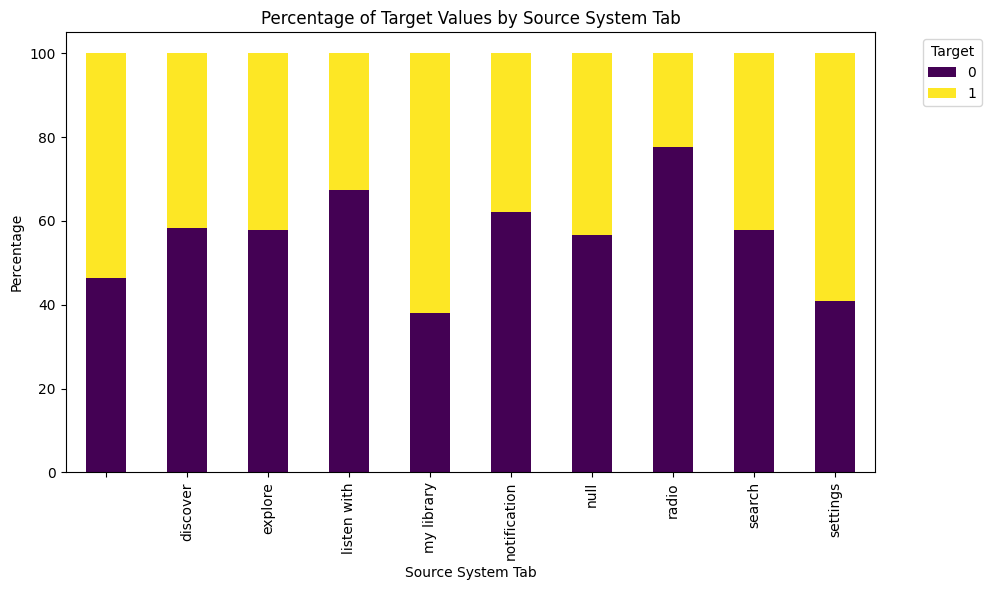

In [14]:
import matplotlib.pyplot as plt

# Calculate the percentage of target values for each source_system_tab
recur_system_tab_percentage = recur_system_tab.div(recur_system_tab.sum(axis=1), axis=0) * 100

# Plot the bar chart
recur_system_tab_percentage.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Percentage of Target Values by Source System Tab')
plt.xlabel('Source System Tab')
plt.ylabel('Percentage')
plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [15]:
recur_source_type = train_df.groupby(['source_type', 'target'],observed=True).size().unstack(fill_value=0)

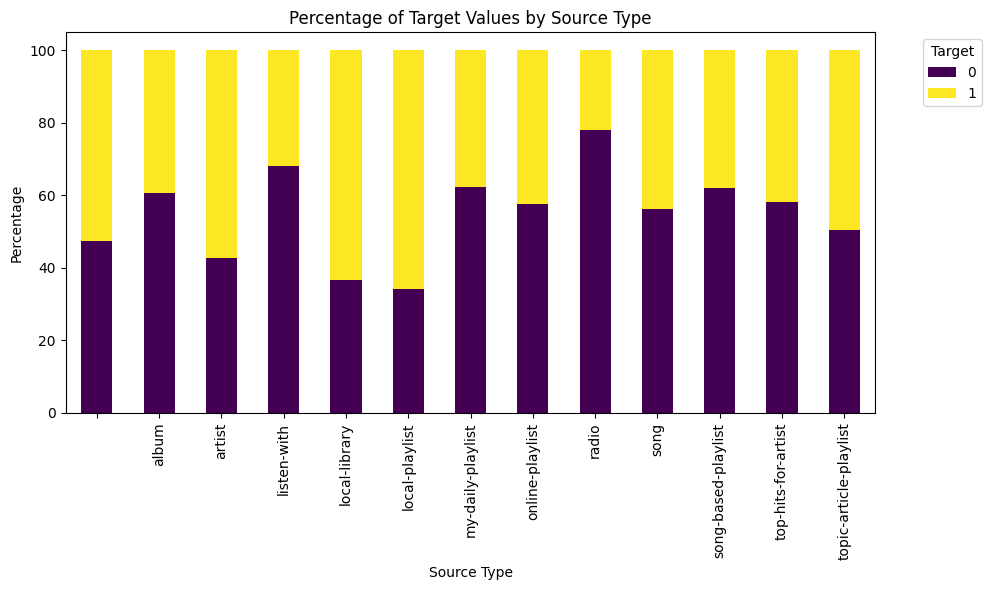

In [16]:
recur_source_type_percentage = recur_source_type.div(recur_source_type.sum(axis=1), axis=0) * 100
recur_source_type_percentage.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Percentage of Target Values by Source Type')
plt.xlabel('Source Type')
plt.ylabel('Percentage')
plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [17]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(cat_feature, target):
    # Create a contingency table
    contingency_table = pd.crosstab(cat_feature, target)
    
    # Perform chi-squared test
    chi2, _, _, _ = chi2_contingency(contingency_table)
    
    # Calculate Cramér's V
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    v = np.sqrt(chi2 / (n * min_dim))
    
    return v

In [18]:
categorical_feature = train_df['source_system_tab']
target = train_df['target']
correlation = cramers_v(categorical_feature, target)
print(f"Cramér's V: {correlation}")

Cramér's V: 0.25102731208244505


In [19]:
categorical_feature = train_df['source_type']
target = train_df['target']
correlation = cramers_v(categorical_feature, target)
print(f"Cramér's V: {correlation}")

Cramér's V: 0.2693056450345676


# Feature Engineering

In [20]:
members_df['registration_init_time'] = members_df['registration_init_time']- 20110101
members_df['expiration_date'] = members_df['expiration_date'] - 20110101

In [21]:
train_df = train_df.merge(members_df, on='msno', how='left')
test_df = test_df.merge(members_df, on='msno', how='left')

In [22]:
train_x = train_df.drop(['target','msno','song_id'], axis=1)
train_y = train_df['target']
test_x = test_df.drop(['msno','song_id'], axis=1)

In [26]:
train_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 15 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   source_system_tab       category
 1   source_screen_name      category
 2   source_type             category
 3   song_length             float64 
 4   genre_ids               category
 5   artist_name             category
 6   composer                category
 7   lyricist                category
 8   language                float16 
 9   city                    int8    
 10  bd                      int16   
 11  gender                  category
 12  registered_via          int8    
 13  registration_init_time  int32   
 14  expiration_date         int32   
dtypes: category(8), float16(1), float64(1), int16(1), int32(2), int8(2)
memory usage: 306.7 MB


# Model Training and Evaluation

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
import pandas as pd

# Split columns by type
cat_cols = train_x.select_dtypes(include='category').columns.tolist()
num_cols = train_x.select_dtypes(exclude='category').columns.tolist()

# Preprocessing pipelines
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

# Full preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_cols),
        ('num', num_pipeline, num_cols)
    ]
)

# Final pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10, min_samples_leaf=5))
])


In [34]:

# Fit the model
model.fit(train_x, train_y)


f:\Anaconda\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
f:\Anaconda\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['source_system_tab',
                                                   'source_screen_name',
                                                   'source_type', 'genre_ids',
                                                   'artist_name', 'composer',
                                                   'lyricist', 'gender']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['song_length', 'language',
                                                   'city', 'bd',
                                                   'registered_via',
                                                   'registration_init_time',
                                                   'expiration_date'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,
                                        min_samples_split=10,
                                        random_state=42))])

In [49]:
model.score(train_x, train_y)


f:\Anaconda\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


0.6252096600734837

In [35]:
test_pred = model.predict(test_x)
submission = pd.DataFrame({'msno': test_df['msno'], 'target': test_pred})
submission.to_csv('submission.csv', index=False)

f:\Anaconda\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [36]:
test_pred

array([1, 1, 0, ..., 0, 0, 0], dtype=int8)

# Result Explanation

In [37]:
tree_model = model.named_steps['classifier']
ohe = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
feature_names = (
    list(ohe.get_feature_names_out(input_features=cat_cols)) +
    num_cols
)

In [56]:
from sklearn.tree import _tree
import numpy as np

def explain_decision_tree_sample(model, preprocessor, feature_names, sample):
    """
    Print the decision rules and prediction for one sample.
    
    Args:
        model: Trained sklearn DecisionTreeClassifier.
        preprocessor: Preprocessing pipeline from ColumnTransformer.
        feature_names: List of feature names after preprocessing.
        sample: A single-row DataFrame (raw, not preprocessed).
    """
    tree = model.tree_
    feature = tree.feature
    threshold = tree.threshold

    # Preprocess test sample
    sample = preprocessor.transform(sample)  # transform into numeric array
    
    node_indicator = model.decision_path(sample)
    leaf_id = model.apply(sample)[0]
    
    print(f"Decision path for sample 0:")
    for node_id in node_indicator.indices[node_indicator.indptr[0] : node_indicator.indptr[1]]:
        if node_id == leaf_id:
            print(f"--> Reached leaf node {node_id}")
            value = tree.value[node_id][0]
            class_prob = value / value.sum()
            predicted_class = model.classes_[np.argmax(class_prob)]
            print(f"    Class distribution at leaf: {value}")
            print(f"    Class probabilities: {class_prob}")
            print(f"    Predicted class: {predicted_class}")
            continue
        feat_name = feature_names[feature[node_id]]
        thresh = threshold[node_id]
        val = sample[0, feature[node_id]]
        decision = "<=" if val <= thresh else ">"
        print(f"Node {node_id}: ({feat_name} = {val:.3f}) {decision} {thresh:.3f}")


In [47]:
from sklearn.tree import _tree

def explain_decision_tree_sample(model, preprocessor, feature_names, sample):
    """
    Print the decision rules for one sample.
    
    Args:
        model: Trained sklearn DecisionTreeClassifier (not in a pipeline).
        feature_names: List of feature names.
        sample: 1D array or DataFrame row of a single sample (after preprocessing).
    """
    tree = model.tree_
    feature = tree.feature
    threshold = tree.threshold

    # Preprocess test sample
    sample = preprocessor.transform(sample)  # this is now numeric
    
    node_indicator = model.decision_path(sample)
    leaf_id = model.apply(sample)[0]
    
    sample_id = 0  # we assume only one sample

    print(f"Decision path for sample {sample_id}:")
    for node_id in node_indicator.indices[node_indicator.indptr[sample_id]:
                                           node_indicator.indptr[sample_id + 1]]:
        if leaf_id == node_id:
            print(f"--> Reached leaf node {node_id}")
            continue
        feat_name = feature_names[feature[node_id]]
        thresh = threshold[node_id]
        val = sample[0, feature[node_id]]
        decision = "<=" if val <= thresh else ">"
        print(f"Node {node_id}: ({feat_name} = {val:.3f}) {decision} {thresh:.3f}")

In [57]:
ohe = model.named_steps['preprocessor']
explain_decision_tree_sample(tree_model, ohe, feature_names, test_x.iloc[0:1])

Decision path for sample 0:
Node 0: (source_screen_name_Local playlist more = 1.000) > 0.500
Node 32: (expiration_date = 60817.000) > 60005.500
Node 48: (source_system_tab_my library = 1.000) > 0.500
Node 56: (registration_init_time = 50118.000) > 20512.500
Node 60: (lyricist_ = 1.000) > 0.500
--> Reached leaf node 62
    Class distribution at leaf: [0.35798328 0.64201672]
    Class probabilities: [0.35798328 0.64201672]
    Predicted class: 1


In [58]:
model.predict(test_x.iloc[0:1])

array([1], dtype=int8)